# Building a Large Language Model From Scratch

## Working with Text Data

### Tokenization


The dataset is “The Verdict"

#### Downloading the dataset.

`urllib.request.urlretrieve(url, file_path)` is used to download the dataset from the given URL and save it to the specified file path.

In [23]:
# Fix the SSL Certificate Error
# Ref: https://github.com/tskit-dev/tutorials/issues/139#issue-1023692234

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [24]:
import urllib.request

url = ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
       "the-verdict.txt")
file_path = "the-verdict.txt"

urllib.request.urlretrieve(url, file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0x10ad1e660>)

#### Reading the dataset.

Using `with open(file_path, "r") as file:` to read the dataset as text sample into Python.

In [25]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total number of characters:", len(raw_text))
print(raw_text[:55])

Total number of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius


Simple tokenization method like regular expression.

Using `re` library to tokenize the text sample.

In [26]:
# An example

import re

text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text) 
result = [item.strip() for item in result if item.strip()] 

print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


#### Tokenizing the dataset

In [27]:
# Used upon the dataset

preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

print(f"The number of tokens: {len(preprocessed)}")
print(f"The first 30 tokens: {preprocessed[:30]}")


The number of tokens: 4690
The first 30 tokens: ['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


##### Converting tokens into token IDs

Sorting and removing duplicates

In [28]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)

print("The size of vocab:", vocab_size)

The size of vocab: 1130


##### Creating a vocabulary

In [29]:
vocab = {token:integer for integer, token in enumerate(all_words)}

for i, item in enumerate(vocab.items()):
    print(item)
    
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


##### Implementing a simple text tokenizer

In [30]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s, i in vocab.items()}

    def encode(self, text):
        # tokenize the text into words and punctuation
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        # convert preprocessed tokens to token ids
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        # convert token ids back to text
        text = " ".join([self.int_to_str[i] for i in ids])
        # remove spaces before the punctuation.
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [31]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know," 
       Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)

print(ids)
print(tokenizer.decode(ids))

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]
" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


##### Adding special context tokens

Let’s now modify the vocabulary to include these two special tokens, `<unk>` and `<|endoftext|>`, by adding them to our list of all unique words.

* `<|endoftext|>`: This token marks the **end of a text sequence**.
* `<|unk|>`: This token is used to replace any **out-of-vocabulary words**.

Using `.extend()`

In [32]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:integer for integer,token in enumerate(all_tokens)} 

print(len(vocab.items()))

for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

1132
('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


##### Updating the tokenizer to handle unknown words

In [33]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)         
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()         
        ]
        preprocessed = [item if item in self.str_to_int else "<|unk|>" for item in preprocessed]
        ids = [self.str_to_int[s] for s in preprocessed]         
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [34]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join([text1, text2])

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [35]:
tokenizer = SimpleTokenizerV2(vocab) 

print(tokenizer.encode(text))
print(tokenizer.decode(tokenizer.encode(text)))

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]
<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


Depending on the LLM, some researchers also consider additional special tokens such as the following:
* `[BOS]` (**beginning of sequence**) — This token marks the start of a text. It signifies to the LLM where a piece of content begins.
* `[EOS]` (**end of sequence**) — This token is positioned at the end of a text and is especially useful when concatenating multiple unrelated texts, similar to <|endoftext|>. 
* `[PAD]` (**padding**) — When training LLMs with batch sizes larger than one, the batch might contain texts of **varying lengths**. To **ensure all texts have the same length**, the shorter texts are extended or “padded” using the `[PAD]` token, up to the length of the longest text in the batch.

**Tokenizer in GPT.**

The tokenizer used for **GPT** models does not need any of these tokens; it only uses an `<|endoftext|>` token for **simplicity**. `<|endoftext|>` is analogous to the `[EOS]` token. `<|endoftext|>` is also used for padding. When training on **batched inputs**, we typically **use a mask**, meaning we don’t attend to padded tokens.

Moreover, the tokenizer used for GPT models also **doesn’t use an `<|unk|>` token** for out-of-vocabulary words. Instead, GPT models use a **byte pair encoding**(BPE) tokenizer, which breaks words down into **subword units**(**sub-word tokenization**), which we will discuss next.

#### Byte Pair Encoding (BPE)

The BPE tokenizer was used to train LLMs such as GPT-2, GPT-3, and the original model used in ChatGPT.

The _tiktoken_ library is a Python library that implements the BPE tokenizer used in GPT models.

In [36]:
%pip install tiktoken


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [38]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)
print(tokenizer.decode(integers))


[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]
Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


Note:
* First, the `<|endoftext|>` token is assigned a relatively **large** token ID, namely, `50256`. In fact, the BPE tokenizer, which was used to train models such as GPT-2, GPT-3, and the original model used in ChatGPT, has a **total vocabulary size of 50,257**, with `<|endoftext|>` being assigned the largest token ID.
* Second,  the  BPE  tokenizer  encodes  and  decodes  unknown  words,  such  as someunknownPlace, correctly. The **BPE tokenizer can handle any unknown word**.

The algorithm underlying BPE **breaks down words** that aren’t in its predefined vocabulary **into smaller subword units or even individual characters**, enabling it to handle **out-of-vocabulary words**.

### Data sampling with a sliding window

The next step in creating the embeddings for the LLM is to generate the input–target pairs required for training an LLM.

In [39]:
# Using BPE to tokenize the text

with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)

print(len(enc_text))

5145


In [40]:
enc_sample = enc_text[50:]

One of the easiest and most intuitive ways to create the input–target pairs for the next-word prediction task is to **create two variables, x and y**, where x contains the input tokens and y contains the targets, which are the inputs shifted by 1

In [41]:
context_size = 4 # how many tokens to use as input
x = enc_sample[ : context_size]
y = enc_sample[1 : context_size + 1]
print(f"x: {x}")
print(f"y:       {y}")


x: [290, 4920, 2241, 287]
y:       [4920, 2241, 287, 257]


In [42]:
for i in range(1, context_size + 1):
    context = enc_sample[ : i]
    desired = enc_sample[i]
    print(context, "----->", desired)

[290] -----> 4920
[290, 4920] -----> 2241
[290, 4920, 2241] -----> 287
[290, 4920, 2241, 287] -----> 257


In [43]:
# convert the token IDs into text
for i in range(1, context_size + 1):
    context = enc_sample[ : i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "----->", tokenizer.decode([desired]))

 and ----->  established
 and established ----->  himself
 and established himself ----->  in
 and established himself in ----->  a


### Dataset & Dataloader

The next step is to implement an efficient **data loader** that iterates over the input dataset and returns the context and desired token IDs.

We will use PyTorch’s built-in `Dataset`  and `DataLoader` classes.

In particular, we are interested in **returning two tensors**: an input tensor containing the text that the LLM sees and a target tensor that includes the targets for the LLM to predict.


#### Creating the PyTorch dataset

In [44]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

#### Creating the PyTorch dataloader

In [45]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )

    return dataloader

Testing the dataloader with `batch_size = 1` and `max_length = 4`.

Note that an input size of 4 is quite **small** and only chosen for **simplicity**. It is common to train LLMs with input sizes of **at least 256**.

In [46]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)
data_iter = iter(dataloader)
first_batch = next(data_iter)

print("First batch: ", first_batch)

First batch:  [tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


### Creating the embeddings

Using `torch.nn.Embedding(vocab_size, output_dim)` to create the embedding layer.

In [47]:
# Suppose the embedding dimension is 3 and the size of vocabulary is 10000.

vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

print(embedding_layer.weight)
print(embedding_layer(torch.tensor([3])))


Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)
tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [48]:
input_ids = torch.tensor([2, 3, 5, 1])

print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


In [49]:
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [50]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length,
    stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, outputs = next(data_iter)

print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [51]:
token_embeddings = token_embedding_layer(inputs)

print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [52]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))

print(pos_embeddings.shape)

torch.Size([4, 256])


In [53]:
input_embeddings = token_embeddings + pos_embeddings

print(input_embeddings.shape)

torch.Size([8, 4, 256])


--------

## The Attention Mechanisms

### Self-attention

#### A simple attention without trainable parameters

In [54]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

print(inputs)
print(inputs.shape)

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])
torch.Size([6, 3])


Self-attention is a mechanism that allows each position in the input sequence to
consider the relevancy of, or “attend to,” all other positions in the same sequence
when computing the representation of a sequence

In self-attention, our goal is to calculate context vectors z(i) for each element x(i)
in the input sequence. A context vector can be interpreted as an enriched embedding
vector.

The context vector purpose is to create enriched representations of each element in an input sequence (like a sentence) by incorporating information from all other elements in the sequence.

In [55]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


The main goal behind the normalization is to obtain attention weights that sum up to 1. This normalization is a convention that is useful for interpretation and maintaining training stability in an LLM.

In practice, it’s more common and advisable to use the **softmax function for normalization**. This approach is better at managing extreme values and offers more favorable
**gradient** properties during training.

In [56]:
# normalizing the attention score
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("Sum", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum tensor(1.0000)


* The softmax function also meets the objective and normalizes the attention weights such that they **sum to 1**.
* In addition, the softmax function ensures that the attention weights are always **positive**. This makes the output interpretable as probabilities or relative importance,
where higher weights indicate greater importance.

In [57]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


Note that this **naive softmax** implementation (`softmax_naive`) may **encounter numerical instability** problems, such as **overflow and underflow**, when dealing with large or small input values. 

Therefore, in practice, it’s **advisable** to use the **PyTorch implementation of softmax**, which has been extensively optimized for performance

In [58]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights:", attn_weights_2)
print("Sum", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum tensor(1.)


Thus, context vector `z(2)` is the weighted sum of all input vectors, obtained by multiplying each input vector by its corresponding attention weight.

In [59]:
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i] * x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


#### Computing attention weights for all input tokens

Each element in the tensor represents an attention score between each pair of inputs.

In [60]:
attn_scores = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


When computing the preceding attention score tensor, we used for loops in Python. However, **`for` loops are generally slow**, and we can achieve the same results **using matrix multiplication**.

In [61]:
attn_scores = inputs @ inputs.T

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In the context of using PyTorch, the `dim` parameter in functions like `torch.softmax`
specifies the **dimension of the input tensor along which the function** will be computed.

By setting `dim=-1`, we are instructing the softmax function to apply the normalization along the **last dimension** of the `attn_scores` tensor. If `attn_scores` is a two-dimensional tensor, it will **normalize across the columns** so that the values in each row (summing over the column dimension) sum up to 1.

In [62]:
attn_weights = torch.softmax(attn_scores, dim=-1)

print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [63]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [64]:
all_context_vecs = attn_weights @ inputs

print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


#### A self-attention with trainable weights

The most notable **difference** is the introduction of weight matrices that are updated during model training which can learn to produce “good” context vectors.

##### Attention step by step

We start here by computing only one context vector $z^{(2)}$.

In [65]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

Note that in GPT-like models, the input and output dimensions are **usually the same**. Here we’ll use different input (`d_in=3`) and output (`d_out=2`) dimensions.

We set `requires_grad=False` to **reduce clutter in the outputs**, but if we were to use the weight matrices **for model training**, we would set `requires_grad=True` to **update** these matrices during model training.

In [66]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

print(query_2)

tensor([0.4306, 1.4551])


We still require the **key and value vectors for all input elements** as they are involved in computing the attention weights with respect to the query $q^{(2)}$

In [67]:
keys = inputs @ W_key
values = inputs @ W_value

print("Shape of keys:", keys.shape)
print("Shape of values:", values.shape)


Shape of keys: torch.Size([6, 2])
Shape of values: torch.Size([6, 2])


In [68]:
keys_2 = keys[1]
attn_scores_22 = query_2.dot(keys_2)

print(attn_scores_22)

tensor(1.8524)


In [69]:
attn_scores_2 = query_2 @ keys.T

print(attn_scores_2)
print(attn_scores_2.shape)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])
torch.Size([6])


In [70]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)

print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [71]:
context_vec_2 = attn_weights_2 @ values

print(context_vec_2)

tensor([0.3061, 0.8210])


##### Attention for PyTorch class

In [72]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))
    
    def forward(self, x):
        queries = x @ self.W_query
        keys = x @ self.W_key
        values = x @ self.W_value
        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [73]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)

print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


improve the `SelfAttention_v1` implementation further by utilizing PyTorch’s `nn.Linear` layers, which effectively perform matrix multiplication when the bias units are disabled.

Another **advantage** of `nn.Linear` instead of `nn.Parameter()` is that it has an **optimized weight initialization** scheme, contributing to **more stable and effective model training**.

In [74]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    
    def forward(self, x):
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [75]:
torch.manual_seed(789)

sa_v2 = SelfAttention_v2(d_in, d_out)

print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


Note that `SelfAttention_v1` and `SelfAttention_v2` give **different outputs** because
they use dif**ferent initial weights** for the weight matrices since `nn.Linear` uses a more
sophisticated weight initialization scheme

#### Causal Attention(Masked Self-Attention)

Causal attention, also known as masked attention, is a specialized form of self-
attention. It restricts a model to only consider previous and current inputs in a sequence
when processing any given token when computing attention scores.

For each token processed, we **mask out** the future tokens, which come after the current token in the input text.

In [76]:
queries = sa_v2.W_query(inputs)    
keys = sa_v2.W_key(inputs) 
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1) 
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


Using PyTorch’s `tril` function to create a mask where the values above the diagonal are zero.

In [77]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))

print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


Multiply this mask with the attention weights to zero-out the values above the diagonal:

In [78]:
masked_simple = attn_weights * mask_simple

print(masked_simple)
print(masked_simple.shape)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)
torch.Size([6, 6])


Renormalize the attention weights to sum up to 1 again in each row. We can achieve this by dividing each element in each row by the sum in each row.

In [79]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums

print(masked_simple_norm)
print(masked_simple_norm.shape)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)
torch.Size([6, 6])


In simpler terms, after masking and renormalization, the distribution of attention
weights is as if it was calculated **only among the unmasked positions** to begin with.
This ensures there’s **no information leakage** from future (or otherwise masked)
tokens as we intended.

We can optimize the causal attention to calculate more efficiently in fewer steps: The softmax function converts its inputs into a probability distribution. When **negative infinity values** (`-∞`) are present in a row, the softmax function treats them as **zero probability**.

We can achieve this by creating a mask with `1`s above the diagonal and then replacing these `1`s with **negative infinity (-inf) values** using `torch.triu()`.

Note:
* `torch.triu()` creates a **upper triangular matrix** with `1`s **above the diagonal** and `0`s below the diagonal.
* `torch.tril()` creates a **lower triangular matrix** with `1`s **below the diagonal** and `0`s above the diagonal.

In [80]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)

print(masked)
print(masked.shape)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)
torch.Size([6, 6])


Applying `softmax` to normalize it.

In [81]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)

print(attn_weights)
print(attn_weights.shape)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)
torch.Size([6, 6])


Another minor tweak for causal attention is that we can use **dropout** to reduce the probability of overfitting when training LLMs.

Dropout in deep learning is a technique where **randomly** selected **hidden layer units
are ignored during training**, effectively “dropping” them out. This method helps **prevent overfitting** by ensuring that a model does not become overly reliant on any specific set of hidden layer units. It’s important to emphasize that dropout is **only used during training** and **is disabled afterward**.

In the transformer architecture, including models like GPT, **dropout** in the attention mechanism is typically **applied at two specific times**: 
* **after** calculating the attention weights or
* **after** applying the **attention weights to the value vectors**.

We will apply the dropout mask after computing the attention weights because it’s the more common variant in practice.

We use a dropout rate of `50%`(but when training, the rate would be lower).

In [82]:
torch.manual_seed(123)

dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)

print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [83]:
torch.manual_seed(123)

print(dropout(attn_weights))


tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


Note that the resulting dropout outputs may look **different** depending on your operating system.

##### Causal Attention for Pytorch Class

In [84]:
batch = torch.stack((inputs, inputs), dim=0)

print(inputs.shape)
print(batch.shape)

torch.Size([6, 3])
torch.Size([2, 6, 3])


The use of `register_buffer` in PyTorch is **not strictly necessary** for all use cases but offers several **advantages** here: buffers are **automatically moved to the appropriate device** (CPU or GPU) along with our model, which will be relevant when training our LLM. This means we **don’t need to manually ensure these tensors are on the same device** as your model parameters, **avoiding device mismatch errors**.

In [85]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2)
        # The operation with `_`(underscore) is in-place operation 
        # which could avoid unnecessary memory allocation.
        attn_scores.masked_fill(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)
        context_vec = attn_weights @ values

        return context_vec

In [86]:
torch.manual_seed(123)

context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)

print("context_vecs shape:", context_vecs.shape)

context_vecs shape: torch.Size([2, 6, 2])


#### Multi-Head Attention

##### Stacking multiple single-head attention layer

The main idea behind multi-head attention is to run the attention
mechanism multiple times (in parallel) with different, learned linear projections—the
results of multiplying the input data (like the query, key, and value vectors in attention
mechanisms) by a weight matrix.

In [87]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) for _ in range(num_heads)]
        )
    
    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [88]:
torch.manual_seed(123)

context_length = batch.shape[1]
d_in, d_out = 3, 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)

tensor([[[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
torch.Size([2, 6, 4])


However, these are processed **sequentially** via `[head(x) for head in self.heads]` in the forward method. We can improve this implementation by **processing the heads in parallel** via **matrix multiplication**.

##### Implementing multi-head attention with weight splits

**Splits the input into multiple heads** by reshaping the projected query, key, and value
tensors and then **combines the results** from these heads after computing attention.

The splitting of the query, key, and value tensors is achieved through tensor **reshaping** and **transposing** operations using PyTorch’s `.view` and `.transpose` methods. The input is first transformed (via linear layers for queries, keys, and values) and then reshaped to represent multiple heads.

The key operation is to split the `d_out` dimension into `num_heads` and `head_dim`, where `head_dim = d_out / num_heads`. This splitting is then achieved using the `.view` method: a tensor of dimensions `(b, num_tokens, d_out)` is reshaped to dimension `(b, num_tokens, num_heads, head_dim)`.

The tensors are then **transposed** to bring the `num_heads` dimension **before** the `num_ tokens` dimension, resulting in a shape of `(b, num_heads, num_tokens, head_dim)`. This **transposition** is **crucial** for **correctly aligning** the queries, keys, and values **across the different heads** and performing batched matrix multiplications efficiently.

In [89]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        # Reduce the projection dim to match the expected input dimension
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        # A linear layer to combine head outputs
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
        
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)
        # implicitly split the matrix by adding a num_heads dimension
        # unpack the last dim: (num_tokens, d_out) -> (num_tokens, num_heads, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        
        # transpose from shape `(b, num_tokens, num_heads, head_dim)`
        # to shape `(b, num_heads, num_tokens, head_dim)`
        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)
        
        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        # Tensor shape: (b, num_tokens, n_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)
        # Combines heads, `self.d_out = self.heads * self.head_dim`
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        # Adds an optional linear projection
        context_vec = self.out_proj(context_vec)
        return context_vec

In [90]:
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],
                    [0.8993, 0.0390, 0.9268, 0.7388],                     
                    [0.7179, 0.7058, 0.9156, 0.4340]],

                   [[0.0772, 0.3565, 0.1479, 0.5331],
                   [0.4066, 0.2318, 0.4545, 0.9737],
                   [0.4606, 0.5159, 0.4220, 0.5786]]]])

print(a.shape)
print(a @ a.transpose(2, 3))

torch.Size([1, 2, 3, 4])
tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


For comparison, the smallest GPT-2 model (117 million parameters) has 12 atten- tion heads and a context vector embedding size of 768. The largest GPT-2 model (1.5 billion parameters) has 25 attention heads and a context vector embedding size of 1,600. The embedding sizes of the token inputs and context embeddings are the same in GPT models (d_in = d_out).

In [91]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2) 
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


---

## Implementing a GPT model

The configuration dict for GPT2 model.

In [92]:
# GPT configs
GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of transformer blocks
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False, # Query-Key-Value bias 
}

### A dummy GPT Class. 

Note that the LayerNorm and Transformer Block are not implemented yet.

In [93]:
# A placeholder GPT model architecture class
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
            for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    
    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    
    def forward(self, x):
        return x

In [94]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

print(batch)
print(batch.shape)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4])


In [95]:
torch.manual_seed(123)

model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)

print('Output shape:', logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### Layer Normalization

**Training** deep neural networks with **many layers** can sometimes prove **challenging**
due to problems like **vanishing or exploding gradients**, leading to **unstable training** dynamics and make the network **difficult to effectively adjust its weights**.

The **layer normalization** to improve the **stability and efficiency of neural network training**. The idea is to adjust the **activations (outputs)** of a neural network layer to **have a mean of 0 and a variance of 1**, also known as unit variance. This **speeds up the convergence** to effective weights and ensures consistent, reliable training. In GPT-2, layer normalization is typically applied **before and after the multi-head attention module**.

In [96]:
torch.manual_seed(123)

batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)

print(out)
print(out.shape)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
torch.Size([2, 6])


Using `keepdim=True` in operations like mean or variance calculation ensures that the
**output tensor retains the same number of dimensions as the input tensor**, even though
the operation reduces the tensor along the dimension specified via `dim`.

* `dim=1` or `dim=-1` calculates mean **across the column** dimension to obtain **one mean per row**.
* `dim=0` calculates mean **across the row dimension** to obtain **one mean per column**.

For a **two-dimensional** tensor (like a matrix), using `dim=-1` for operations such as mean or
variance calculation is **the same as** using `dim=1`. This is because -1 refers to the tensor’s last dimension, which corresponds to the columns in a two-dimensional tensor.

In [97]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


Apply layer normalization: The operation consists of **subtracting the mean** and **dividing by the square root of the variance** (also known as the standard deviation).

In [98]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)

print("Normalized output:", out_norm)
print("Normalized output mean:", mean)
print("Normalized output variance:", var)


Normalized output: tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Normalized output mean: tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Normalized output variance: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Note that the value –5.9605e-08 in the output tensor is the scientific notation for, which is 0.000000059605 in decimal form. This value is **very close to 0**, but it is not exactly 0 due to **small numerical errors** that can accumulate because of the finite precision **with which computers represent numbers**.

To improve **readability**, we can also **turn off the scientific notation** when printing
tensor values by setting `sci_mode` to `False`

In [99]:
torch.set_printoptions(sci_mode=False)

print("Mean:", mean)
print("Var:", var)

Mean: tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Var: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### LayerNorm Pytorch class

In [100]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

This specific implementation of layer normalization operates on the **last dimension** of
the input tensor x, which represents the embedding dimension (`emb_dim`).

The variable `eps` is a **small constant (epsilon)** added to the variance to **prevent division by zero** during normalization.

The `scale` and `shift` are two **trainable** parameters (of the same dimension as the input) that the LLM automatically adjusts during training if it is determined that doing so would
**improve the model’s performance** on its training task.

This allow model to **learn appropriate scaling and shifting** that best suit the data it is processing.

We divide by the number of inputs `n` in the variance formula. This approach **does not apply Bessel’s correction**, which typically uses `n – 1` instead of `n` in the denominator to **adjust for bias** in sample variance estimation. This is called _biased estimate of the variance_. For LLMs, where the embedding dimension `n` is **significantly large**, the difference between using `n` and `n – 1` is **practically negligible**.

In [101]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:", mean)
print("Variance:", var)


Mean: tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Unlike **batch normalization**, which normalizes **across the batch dimension**, **layer normalization** normalizes **across the feature dimension**.

Since layer normalization normalizes each input independently of the batch size, it offers more **flexibility** and **stability**. It's beneficial for **distributed training** and **resource-constrained environments**.


### GELU with Feed Forward

In LLMs, several other activation functions are employed beyond the traditional ReLU. Two notable examples are **GELU** (Gaussian error linear unit) and **SwiGLU**
(Swish-gated linear unit). They are more **complex** and **smooth**, incorpo-
rating Gaussian and sigmoid-gated linear units, respectively. 

They offer **improved performance**.

The GELU can be implemented in several ways:
* the **exact version** is defined as $GELU(x) = x⋅Φ(x)$, where $Φ(x)$ is the **cumulative distribution function** of the **standard Gaussian distribution**.
* the **approximation version** is defined as $GELU(x) = 0.5x(1 + tanh(√2/π(x + 0.044715x^3)))$, which is a **simplified form** of the exact version.

In [102]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [103]:
%pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


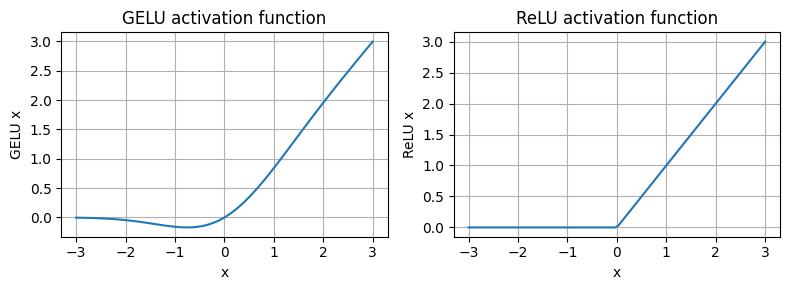

In [104]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))

for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label} x")
    plt.grid(True)
plt.tight_layout()
plt.show()

**ReLU (right)** is a **piecewise linear** function that outputs the input directly if it is positive; otherwise, it outputs zero.

**GELU (left)** is a **smooth**, **nonlinear** function that **approximates ReLU** but with **a non-zero gradient** for **almost all negative** values (except at approximately x = –0.75).

GELU lead to **better optimization** properties during training, as it allows **more nuanced adjustments** to the model’s parameters. GELU allows for a small, non-zero output for negative values. It means that during the training process, neurons that **receive negative input can still contribute to the learning process**, albeit to a lesser extent than positive inputs.

In [105]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )
    
    def forward(self, x):
        return self.layers(x)

In [106]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)

print(out)
print(out.shape)

tensor([[[ 0.1238,  0.0457,  0.0939,  ...,  0.1107,  0.0167, -0.1992],
         [ 0.1574, -0.0282,  0.0049,  ...,  0.0026,  0.1120, -0.1075],
         [ 0.1184, -0.0052,  0.0839,  ...,  0.1662,  0.0112, -0.1685]],

        [[ 0.1302,  0.0630,  0.1050,  ...,  0.1439,  0.0562, -0.1128],
         [ 0.1249, -0.0073,  0.1022,  ...,  0.0417,  0.0381, -0.0828],
         [ 0.0494,  0.0654,  0.0347,  ...,  0.0701,  0.0793, -0.1810]]],
       grad_fn=<ViewBackward0>)
torch.Size([2, 3, 768])


The Feed Forward module plays a crucial role in enhancing the model’s ability to **learn
from and generalize the data**.

The feed forward network **internally** **expands** the **embedding dimension** into a higher-dimensional space through the first linear layer. This expansion is followed by a **nonlinear** **GELU** activation and then a **contraction** **back** to the original dimension with the second linear transformation. Such a design allows for the **exploration of a richer representation space**.

Moreover, the **uniformity in input and output dimensions** simplifies the architecture
by enabling the stacking of multiple layers, thus making the model **more scalable**.

### Residual Connection

The **shortcut connections**, also known as **skip** or **residual** connections.

It can **mitigate the challenge of vanishing gradients** by allowing the gradient to flow directly through the network.

The vanishing gradient problem refers to the issue where gradients (which guide weight updates during training) become progressively smaller as they propagate backward through the layers, making it difficult to effectively train earlier layers.


In [107]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(layer_sizes[0], layer_sizes[1]),
                GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[1], layer_sizes[2]),
                GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[2], layer_sizes[3]),
                GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[3], layer_sizes[4]),
                GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[4], layer_sizes[5]),
                GELU()
            ),
            
        ])
    
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = layer_output + x
            else:
                x = layer_output
        return x

In [108]:
layer_sizes = [3, 3, 3, 3, 3, 1]  
sample_input = torch.tensor([[1., 0., -1.]]) 
torch.manual_seed(123)                           
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

In short, the .backward() method is a convenient method in PyTorch that com-
putes loss gradients, which are required during model training, without implement-
ing the math for the gradient calculation ourselves, thereby making working with
deep neural networks much more accessible.

In [109]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward() # backward pass to calculate gradients

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [110]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


The output of the `print_gradients` function shows, the gradients become smaller, a phenomenon called the **vanishing gradient problem**.

In [111]:
torch.manual_seed(123)

model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


The gradient value stabilizes.

### The Transformer Block

The idea is that the self-attention mechanism in the multi-head attention block identifies and analyzes relationships between elements in the input sequence. In contrast, the feed forward network modifies the data individually at each position. This combination not only enables a more nuanced understanding and processing of the input but also enhances the model’s overall capacity for handling complex data patterns.

In [112]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
    
    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

Layer normalization (LayerNorm) is applied **before** each of these two components(MultiHead Attention and Feed Forward), and dropout is applied after them to **regularize the model and prevent overfitting**. This is also known as **Pre-LayerNorm**.

**Older** architectures, such as the original transformer model, applied **layer normalization after** the self-attention and feed forward networks instead, known as **Post-LayerNorm**, which often **leads to worse training dynamics**.

In [113]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input:", x)
print("Input shape:", x.shape)
print("Output:", output)
print("Output shape:", output.shape)

Input: tensor([[[0.2961, 0.5166, 0.2517,  ..., 0.9541, 0.8567, 0.4604],
         [0.2238, 0.3047, 0.3019,  ..., 0.5465, 0.4532, 0.7598],
         [0.6945, 0.2478, 0.4111,  ..., 0.8838, 0.4898, 0.5963],
         [0.0890, 0.7804, 0.9223,  ..., 0.4507, 0.6357, 0.5833]],

        [[0.5716, 0.9297, 0.3396,  ..., 0.0477, 0.4564, 0.2797],
         [0.0936, 0.2211, 0.3806,  ..., 0.3948, 0.4545, 0.4536],
         [0.6788, 0.1741, 0.2084,  ..., 0.5557, 0.5930, 0.0959],
         [0.3894, 0.4083, 0.0662,  ..., 0.9861, 0.9341, 0.1319]]])
Input shape: torch.Size([2, 4, 768])
Output: tensor([[[-0.0055,  0.0972, -0.1122,  ...,  1.2889,  0.2623,  0.6685],
         [ 0.0023, -0.2369,  0.1720,  ...,  0.5952,  0.2497,  0.7447],
         [ 0.4673,  0.4472,  0.1791,  ...,  1.2525,  0.3045,  0.7750],
         [ 0.0662,  0.7224,  0.9206,  ...,  0.4790,  0.7428,  0.7015]],

        [[ 0.3622,  1.2144,  0.5221,  ...,  0.1854,  0.0111, -0.5034],
         [-0.0225,  0.7789,  0.2770,  ...,  0.1734,  0.5419,  0.114

The transformer block **maintains** the **input dimensions in its output**, indicating that the transformer architecture processes sequences of data without altering their shape throughout the network.

### The GPT Model

In [114]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])         
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])         
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(             
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])         
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [115]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
out = model(batch)

print("Input batch:", batch)
print("Output shape", out.shape)
print(out)

Input batch: tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


Using the `numel()` method, short for “number of elements,” we can collect the total
number of parameters in the model’s parameter tensors.

In [116]:
total_params = sum(p.numel() for p in model.parameters())

print(f"Total Parameters: {total_params}")


Total Parameters: 163009536


Earlier, we spoke of initializing a 124-million-parameter GPT model, so why is the number of parameters is different?

The reason is a concept called **weight tying**. The original GPT-2 architecture **reuses** the **weights from the token embedding** layer in its **output layer**.

Weight tying **reduces the overall memory footprint and computational complexity** of the model. However, in practice, using **separate** token embedding and output layers results in **better training and model performance**.


In [117]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


The weight tensors for both these layers have the same shape so that they could be shared.

In [118]:
total_params_gpt2 = (
    total_params - sum(p.numel() for p in model.out_head.parameters())
)


print(f"Number of trainable parameters in GPT-2: {total_params_gpt2}")

Number of trainable parameters in GPT-2: 124412160


The model is now only 124 million parameters large, **matching** the original size of the GPT-2 model. 

In [119]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


### Generating text

Implement the code that converts the tensor outputs of the GPT model back into text.

In [120]:
# `idx` is a `(batch, n_tokens)` array
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        # Crops the text to the last 'context_size' tokens
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focusing on the last step, `(batch, vocab_size)`
        logits = logits[:, -1, :]
        # softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)
        # get the index of the max probability
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        # get the next token
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

The process is known as **greedy decoding**.

we use a `softmax` function to convert the logits into a probability distribution from which we identify the position with the highest value via `torch.argmax`. 

The `softmax` function is **monotonic**, meaning it **preserves the order** of its inputs when transformed into outputs.

In other words, we could **apply** the `torch.argmax` function to the **logits** tensor **directly** and get identical results.

In [121]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

# Adds batch dimension
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


We put the model into `.eval()` mode, this **disables** random components like dropout, which are only used during training.

In [122]:
model.eval()

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [123]:
decoded_text = tokenizer.decode(out[0].squeeze(0).tolist())

print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


The reason the model is unable to produce coherent text is that we haven’t trained it yet.

## Pretraining on unlabeled data

In [124]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,       
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12, 
    "drop_rate": 0.1,      
    "qkv_bias": False,
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

### Utility functions for text to token ID conversion

In [125]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    # Add a batch dimension(`.unsqueeze(0)`)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    # Remove the batch dimension(`.squeeze(0)`)
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
)

print("Output text:", token_ids_to_text(token_ids, tokenizer))

Output text: Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [126]:
inputs = torch.tensor([[16833, 3626, 6100], [40, 1107, 588]])

targets = torch.tensor([[3626, 6100, 345], [1107, 588, 11311]])

In [127]:
# disables gradient tracking
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)

print(probas.shape)

torch.Size([2, 3, 50257])


In [128]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)

print("Token ids:", token_ids)

Token ids: tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [129]:
print(f"Target batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Output batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Target batch 1:  effort moves you
Output batch 1:  Armed heNetflix


### The loss function

The model training aims to **increase the softmax probability in the index positions
corresponding to the correct target token IDs**.

This softmax probability is also used in the evaluation metric we will implement next to numerically assess the model’s generated outputs: the higher the probability in the correct positions, the better.

In [130]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([0.0001, 0.0000, 0.0000])
Text 2: tensor([0.0000, 0.0001, 0.0000])


In [131]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))

print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


Working with **logarithms** of probability scores is **more manageable** in mathematical optimization than handling the scores directly.

Combine these log probabilities into a single score by **computing the average**.

In [132]:
avg_log_probas = torch.mean(log_probas)

print(avg_log_probas)

tensor(-10.7940)


The goal is to get the average log probability as close to 0 as possible by updating the
model’s weights as part of the training process.

However, in deep learning, the common practice isn’t to push the average log probability up to 0 but rather to bring the **negative average log probability down to 0**. The negative average log probability is simply the average log probability multiplied by –1.

In [133]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In [134]:
print("Logits shape:", logits.shape) 
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


For the cross_entropy loss function in PyTorch, we want to flatten these tensors
by combining them over the batch dimension.

In [135]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


Previously, we applied the softmax function, selected the probability scores corresponding to the target IDs, and computed the negative average log probabilities.

PyTorch’s `cross_entropy` function will take care of all these steps.

In [136]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)

print(loss)

tensor(10.7940)


**Perplexity** measures how well the **probability distribution predicted** by the model
**matches the actual distribution** of the words in the dataset.

A **lower** perplexity indicates that the model predictions are **closer** to the actual distribution.

Perplexity can be calculated as `perplexity = torch.exp(loss)`.

Perplexity is often considered **more interpretable** than the raw loss value because it signifies the effective vocabulary size about which the model is uncertain at each step.

In [137]:
perplexity = torch.exp(loss)

print(perplexity)

tensor(48725.8203)


In [138]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [139]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


We are training the model with training data presented in similarly sized chunks for simplicity and efficiency. However, in practice, it can also be **beneficial** to train an LLM **with variable-length inputs** to help the LLM to **better generalize** across different types of inputs when it is being used.

We first define a train_ratio to use 90% of the data for training and the remaining 10% as validation data for model evaluation during training.

In [140]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data)) 
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [141]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [142]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [143]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)            
    target_batch = target_batch.to(device)          
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(         
        logits.flatten(0, 1), target_batch.flatten()     
    )
    return loss

### Compute the training and validation loss

In [144]:
def calc_loss_loader(data_loader, model, device, num_batches=None):     
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:         
        num_batches = len(data_loader)        
    else:
        num_batches = min(num_batches, len(data_loader))  
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device             
            )
            total_loss += loss.item()           
        else:
            break
    return total_loss / num_batches

In [145]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(device)
model.to(device)  

with torch.no_grad():                                          
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
    
print("Training loss:", train_loss) 
print("Validation loss:", val_loss)


cpu
Training loss: 10.987583690219456
Validation loss: 10.981106758117676


The loss values are relatively high because the model has not yet been trained. For comparison, the loss approaches 0 if the model learns to generate the next tokens as they appear in the training and validation sets.

### Training a LLM

In [146]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []   
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):           
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "                       
                    f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen

In [147]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() 
    with torch.no_grad():                             
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [148]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size         
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)     
    print(decoded_text.replace("\n", " "))
    model.train()

Adam optimizers are a popular choice for training deep neural networks.

AdamW is a variant of Adam that **improves** the **weight decay** approach, which aims to **minimize model complexity** and **prevent overfitting** by penalizing larger weights.

AdamW achieve more **effective regularization** and **better generalization**; thus, AdamW is frequently used in the training of LLMs.

In [ ]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933


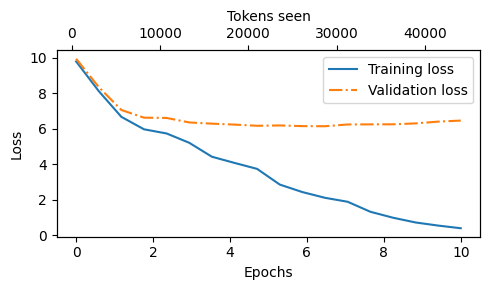

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


However, the losses start to **diverge** past the second epoch. This divergence and the fact that the **validation loss is much larger** than the training loss indicate that the model is **overfitting** to the training data.

This memorization is **expected** since we are working with a very, very small training dataset and training the model for multiple epochs. **Usually**, it’s common to train a model on a **much larger dataset for only one epoch**.

### Decoding and control randomness

In [ ]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:", token_ids_to_text(token_ids, tokenizer))

Output text: Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


The generated token is selected at each generation step corresponding to the **largest probability score** among all tokens in the vocabulary.

The LLM will **always generate the same outputs** even if we run the preceding `generate_text_simple` function multiple times on the same start context.

#### Temperature scaling

**Temperature scaling**, a technique that **adds a probabilistic selection** process to the next-token generation task.

Previously we always **sampled the token with the highest probability** as the next token
using `torch.argmax`, also known as **greedy decoding**.

To generate text with **more variety**, we can **replace** `argmax` with a function that **samples from a probability distribution**.

In [ ]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}

In [ ]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [ ]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

print(inverse_vocab[next_token_id])

forward


To implement a **probabilistic sampling** process, we can now replace `argmax` with the `multinomial` function in PyTorch.

In [ ]:
torch.manual_seed(123)

next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


The `multinomial` function samples the next token **proportional to its probability score**.

We can sample many times to see if `forward` always returns.

In [ ]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()              
    for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)


73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


We can further **control** the distribution and selection process via a concept called
**temperature scaling**. Temperature scaling is just a fancy description for **dividing the logits by a number greater than 0**.

In [ ]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

Temperatures **greater than 1** result in **more uniformly distributed** token probabilities,
and temperatures **smaller than 1** will result in **more confident** (sharper or more peaky)
distributions.

A temperature of `1` divides the logits by 1 before passing them to the softmax function to compute the probability scores. In other words, using a temperature of 1 is **the
same as not using any temperature scaling**.

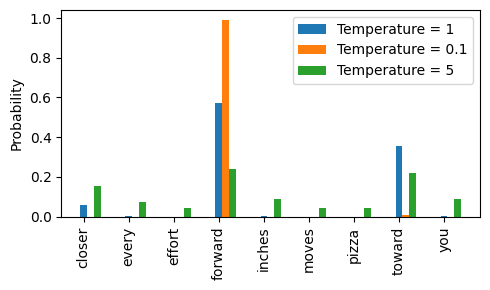

In [ ]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))

for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],                    
    bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()

#### Top-k sampling

The drawback of temperature scaling is that it sometimes leads to **grammatically incorrect** or completely nonsensical outputs.

**Top-k sampling**, when combined with probabilistic sampling and temperature scaling, can **improve** the text generation results. It **restricts the sampled tokens to the top-k most likely tokens** and **exclude all other tokens** from the selection process by masking their probability scores.

The top-k approach **replaces all nonselected logits with negative infinity value (`-inf`)**,
such that when computing the softmax values, the **probability scores** of the non-top-k
tokens are **0**, and the **remaining probabilities sum up to 1**.

In [ ]:
# select tokens with largest logits
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [ ]:
# apply `where` function to replace non-top-k logits with -inf

new_logits = torch.where(
    # set the threshold
    condition=next_token_logits < top_logits[-1],
    # assign `-inf` to non-top-k logits
    input=torch.tensor(float('-inf')),
    # retains the original logits for all other tokens
    other=next_token_logits,
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [ ]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


#### Modifying the text generation function

Combining temperature scaling(applied last) with top-k sampling(applied first).

In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')),
                logits,
            )
        
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            # argmax as the fallback
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [ ]:
torch.manual_seed(123) 

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


#### Loading and saving model weights in PyTorch

The recommended way is to save a model’s `state_dict`, a dictionary mapping each layer to its parameters, using the `torch.save` function.

The `.pth` extension is a convention for PyTorch files, though we could technically use any file extension.

In [ ]:
torch.save(model.state_dict(), "model.pth")

Loading a model using the `torch.load` function.

In [ ]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

During **inference**, we don’t want to randomly drop out any of the information the network has
learned. Using `model.eval()` switches the model to evaluation mode for inference, **disabling
the dropout layers** of the model.

It's also **recommend** to **saving the optimizer state** for **resuming training** later.

Adaptive optimizers such as AdamW store additional parameters for each model weight. AdamW uses historical data to adjust learning rates for each model parameter dynamically. Without it, the optimizer resets, and the model may learn suboptimally or even fail to converge properly.

Using `torch.save`, we can save both the model and optimizer state_dict contents.

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

Then we can restore the model and optimizer states by **first loading the saved data** via `torch.load` and **then** using the `load_state_dict` method.

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1) 
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

### Loading pretrained weights from OpenAI

In [ ]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)

filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x11c809a70>)

In [ ]:
from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

ModuleNotFoundError: No module named 'tensorflow'